# Laboratorio 1 - Series de Tiempo
## Serie: Categoría "Países de Residencia" (Top 3)




In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller, acf, pacf

plt.rcParams['figure.figsize'] = [12, 5]
plt.rcParams['figure.dpi'] = 100
pd.set_option('display.float_format', lambda x: f'{x:,.1f}')


## 1. Carga de datos

Se carga la hoja `Datos` del archivo de migración y se construye una columna de fecha
(`Año` + `Mes cod`) para poder ordenar cronológicamente y agregar mensualmente.


In [8]:
df = pd.read_excel(
    'Laboratorio 1. Series de Tiempo 2026 - Base_Migracion_2009-2026jun.xlsx',
    sheet_name='Datos'
)

df['Fecha'] = pd.to_datetime(df['Año'].astype(str) + '-' + df['Mes cod'].astype(str) + '-01')
df = df.sort_values('Fecha').reset_index(drop=True)

print(f"Rango de fechas: {df['Fecha'].min().date()} a {df['Fecha'].max().date()}")
print(f"Filas totales: {len(df):,}")
df.head()


Rango de fechas: 2009-01-01 a 2026-06-01
Filas totales: 161,036


,Año,Mes cod,Mes,Vía,Frontera,País,Región,Región dos,Regiones OMT,MCEO,Agrupación Residencia,Tipo de Viajero,Viajero,Fecha
0,2009,1,Ene,Aérea,01 La Aurora,Albania,OTROS EUROPEOS,Europa,EUROPA MERIDIONAL,08 OTROS,Europa,Turista,1.0,2009-01-01
1,2009,1,Ene,Terrestre,13 El Cinchado / El Corinto,Suecia,EUROPA,Europa,EUROPA DEL NORTE,08 OTROS,Europa,Turista,11.0,2009-01-01
2,2009,1,Ene,Terrestre,13 El Cinchado / El Corinto,Suiza,EUROPA,Europa,EUROPA OCCIDENTAL,08 OTROS,Europa,Turista,7.0,2009-01-01
3,2009,1,Ene,Terrestre,13 El Cinchado / El Corinto,Trinidad y Tobago,OTROS CARIBEÑOS,América Del Sur y el Caribe,EL CARIBE,08 OTROS,Resto del Mundo,Turista,2.0,2009-01-01
4,2009,1,Ene,Terrestre,13 El Cinchado / El Corinto,Uruguay,OTROS SUDAMERICANOS,América Del Sur y el Caribe,AMÉRICA DEL SUR,08 OTROS,Suramérica,Turista,1.0,2009-01-01


## 2. Consistencia de "Tipo de Viajero"

Tal como advierte el enunciado del laboratorio, entre 2022 y 2023 la categoría **"Viajero"**
cambió de definición (se excluyen viajeros de alta frecuencia / comercio fronterizo), lo que
genera una caída artificial en esa categoría a partir de 2023 que **no refleja una caída real
de turismo**.

Para que las series de "País de Residencia" sean comparables en todo el período (2009–2026),
se construyen usando únicamente **Turista + Excursionista**, que son consistentes en toda la
ventana temporal.


In [9]:
df_cons = df[df['Tipo de Viajero'].isin(['Turista', 'Excursionista'])].copy()

print("Registros originales:", len(df))
print("Registros tras filtrar Turista + Excursionista:", len(df_cons))


Registros originales: 161036
Registros tras filtrar Turista + Excursionista: 137642


## 3. Selección del Top 3 de países

El criterio pedido es el **total acumulado de viajeros durante todo el período de estudio**.


In [10]:
top_paises = df_cons.groupby('País')['Viajero'].sum().sort_values(ascending=False)
top_paises.head(8).to_frame('Viajeros acumulados (Turista+Excursionista)')


,Viajeros acumulados (Turista+Excursionista)
País,
El Salvador,"14,079,135.8"
Guatemala,"13,870,391.3"
Estados Unidos de América,"6,965,679.7"
Honduras,"2,520,974.3"
México,"1,678,422.6"
Belice,"916,101.1"
Costa Rica,"860,240.7"
Nicaragua,"811,145.4"


**Hallazgo importante (calidad de datos):** *Guatemala* aparece en 2do lugar por volumen
acumulado, pero al revisar su serie temporal se descubre que **no tiene ningún registro después
de diciembre de 2022** (ver verificación abajo). Esto no es una caída de la demanda, sino un
**quiebre estructural**: a partir de 2023 el país deja de reportarse como "país de residencia"
en la nueva clasificación de mercados. Incluir esta serie sería problemático porque el conjunto
de prueba (2021-04 en adelante) quedaría prácticamente vacío para este país, imposibilitando una
evaluación real del modelo.

Por esta razón, **se excluye a Guatemala** del Top 3 y se selecciona el siguiente país con mayor
acumulado que sí tiene cobertura completa hasta 2026: **Honduras**.

Top 3 final para "País de Residencia": **El Salvador, Estados Unidos de América, Honduras**.


In [11]:
# Verificación del quiebre estructural en Guatemala
gt = df_cons[df_cons['País'] == 'Guatemala']
print("Última fecha con datos para Guatemala:", gt['Fecha'].max().date())
print("¿Guatemala aparece en el dataset después de 2022?:",
      (df[df['País'] == 'Guatemala']['Fecha'] > '2022-12-01').any())


Última fecha con datos para Guatemala: 2022-12-01
¿Guatemala aparece en el dataset después de 2022?: False


In [12]:
paises_top3 = ['El Salvador', 'Estados Unidos de América', 'Honduras']


## 4. División entrenamiento / prueba (70/30)

En series de tiempo **no se puede dividir al azar** porque el orden importa; se debe respetar la
cronología. Se ordenan los 210 períodos mensuales únicos (Ene-2009 a Jun-2026) y se toma el
primer 70% como entrenamiento y el 30% restante como prueba.


In [13]:
periodos = sorted(df['Fecha'].unique())
n_periodos = len(periodos)
corte_idx = int(n_periodos * 0.7)
fecha_corte = periodos[corte_idx]

print(f"Total de meses en el estudio: {n_periodos}")
print(f"Meses en entrenamiento (70%): {corte_idx}  ->  {periodos[0]} a {periodos[corte_idx-1]}")
print(f"Meses en prueba (30%):        {n_periodos - corte_idx}  ->  {periodos[corte_idx]} a {periodos[-1]}")

train_raw = df_cons[df_cons['Fecha'] < fecha_corte].copy()
test_raw  = df_cons[df_cons['Fecha'] >= fecha_corte].copy()

print(f"\nRegistros en train: {len(train_raw):,}  |  Registros en test: {len(test_raw):,}")


Total de meses en el estudio: 210
Meses en entrenamiento (70%): 147  ->  2009-01-01 00:00:00 a 2021-03-01 00:00:00
Meses en prueba (30%):        63  ->  2021-04-01 00:00:00 a 2026-06-01 00:00:00

Registros en train: 116,966  |  Registros en test: 20,676


## 5. Construcción de las series mensuales

Se agrega el número de viajeros por mes para cada país del Top 3, usando `asfreq('MS')` para
asegurar una frecuencia mensual continua (inicio de mes). Los meses sin registros
(abril–agosto 2020, cierre de fronteras por COVID-19) se completan con **0**, ya que
efectivamente no hubo ingreso de viajeros — no es un dato faltante, es un valor real.


In [14]:
def construir_serie(data, pais, fecha_ini, fecha_fin):
    s = data[data['País'] == pais].groupby('Fecha')['Viajero'].sum()
    idx = pd.date_range(fecha_ini, fecha_fin, freq='MS')
    s = s.reindex(idx, fill_value=0)
    s.index.name = 'Fecha'
    s.name = pais
    return s

series_train = {p: construir_serie(train_raw, p, periodos[0], periodos[corte_idx-1]) for p in paises_top3}
series_test  = {p: construir_serie(test_raw,  p, periodos[corte_idx], periodos[-1])   for p in paises_top3}

resumen = pd.DataFrame({
    p: {
        'Inicio (train)': series_train[p].index.min().date(),
        'Fin (train)': series_train[p].index.max().date(),
        'Obs. train': len(series_train[p]),
        'Inicio (test)': series_test[p].index.min().date(),
        'Fin (test)': series_test[p].index.max().date(),
        'Obs. test': len(series_test[p]),
        'Frecuencia': 'Mensual (MS)'
    } for p in paises_top3
}).T
resumen


,Inicio (train),Fin (train),Obs. train,Inicio (test),Fin (test),Obs. test,Frecuencia
El Salvador,2009-01-01,2021-03-01,147,2021-04-01,2026-06-01,63,Mensual (MS)
Estados Unidos de América,2009-01-01,2021-03-01,147,2021-04-01,2026-06-01,63,Mensual (MS)
Honduras,2009-01-01,2021-03-01,147,2021-04-01,2026-06-01,63,Mensual (MS)


## 6. Análisis preliminar por serie (conjunto de entrenamiento)

Para cada país se revisa: el gráfico de la serie, su descomposición (tendencia, estacionalidad,
residuo), un primer diagnóstico visual de estacionariedad en media/varianza (media y desviación
estándar móvil), la función de autocorrelación (ACF) y la prueba de Dickey-Fuller Aumentada (ADF).

Este es un análisis **preliminar**: la elección final de parámetros ARIMA/SARIMA, el modelado
completo (ARIMA, Prophet, Holt-Winters, suavizamiento exponencial) y las métricas de comparación
se desarrollarán en la entrega final.


PAÍS: El Salvador
Inicio: 2009-01-01  |  Fin: 2021-03-01  |  Frecuencia: Mensual
Número de observaciones: 147
Media: 54,786  |  Desv. estándar: 28,261  |  Mínimo: 0  |  Máximo: 131,339


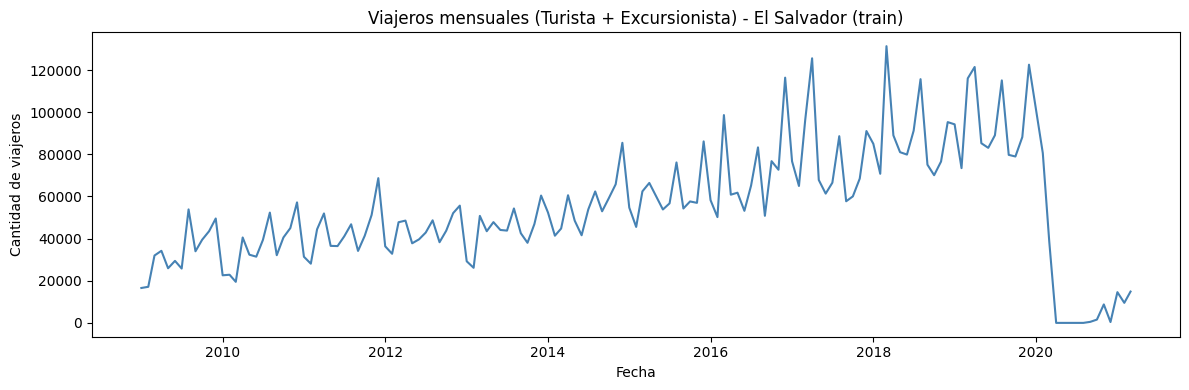

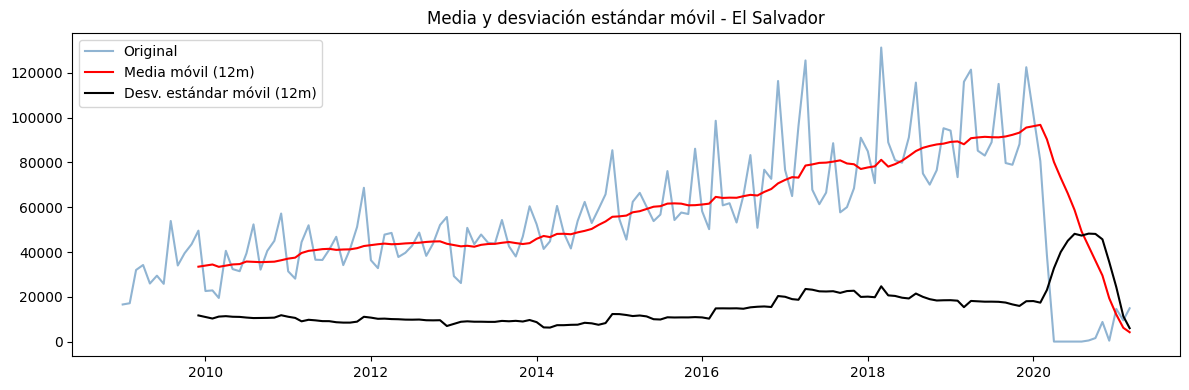

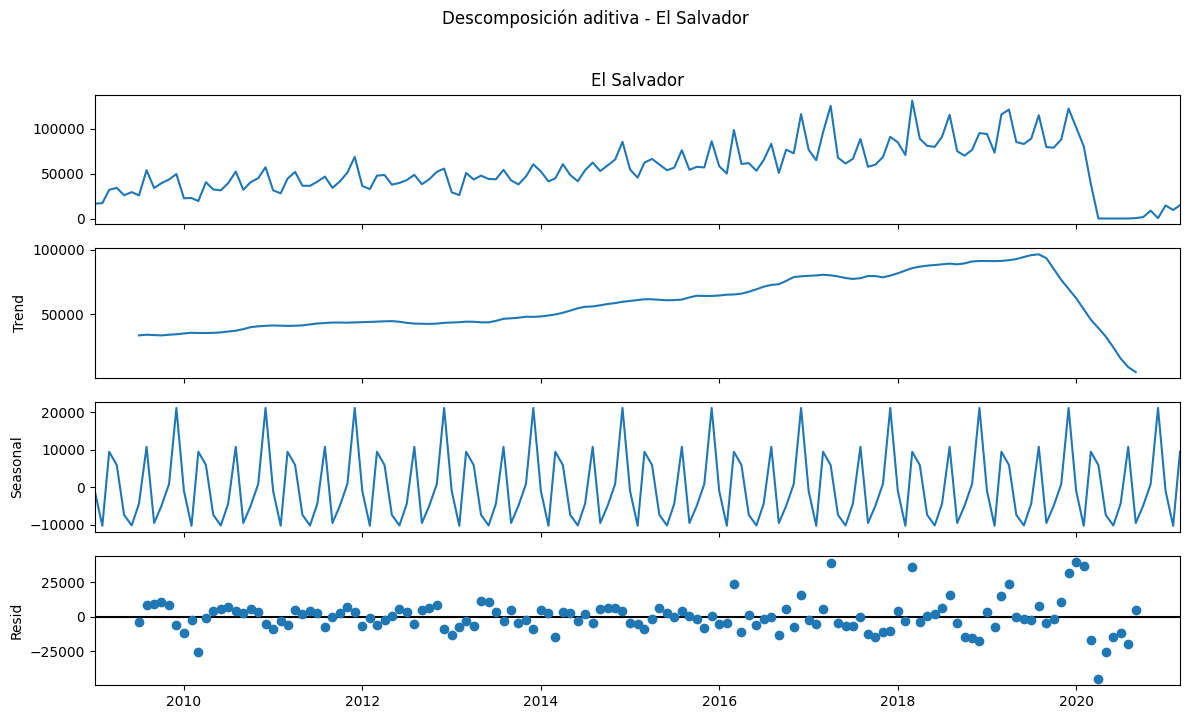

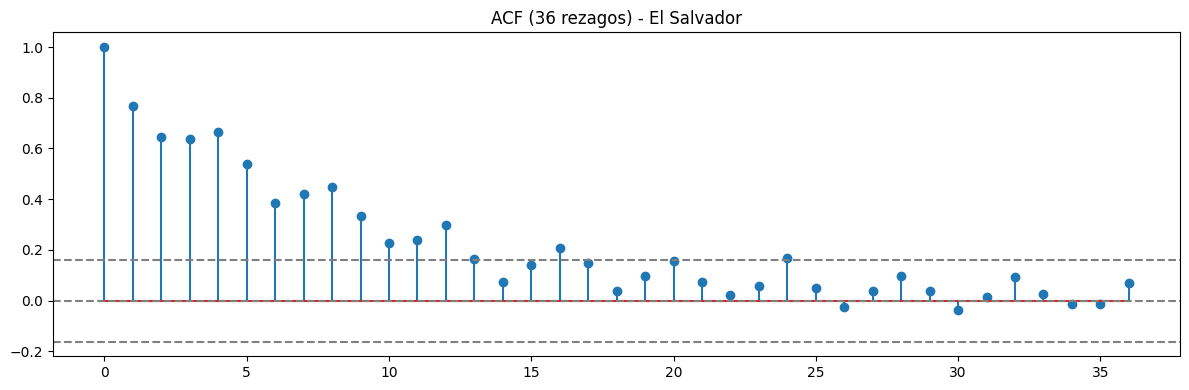


Prueba de Dickey-Fuller Aumentada (nivel):
Estadístico de prueba     -1.9
p-value                    0.3
# rezagos usados          12.0
# observaciones usadas   134.0
Valor crítico (1%)        -3.5
Valor crítico (5%)        -2.9
Valor crítico (10%)       -2.6
dtype: float64
PAÍS: Estados Unidos de América
Inicio: 2009-01-01  |  Fin: 2021-03-01  |  Frecuencia: Mensual
Número de observaciones: 147
Media: 27,682  |  Desv. estándar: 10,936  |  Mínimo: 0  |  Máximo: 54,288


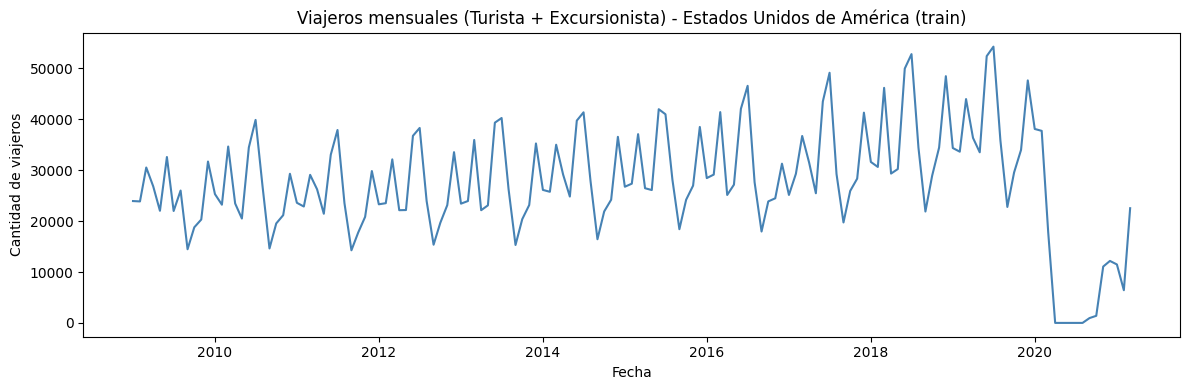

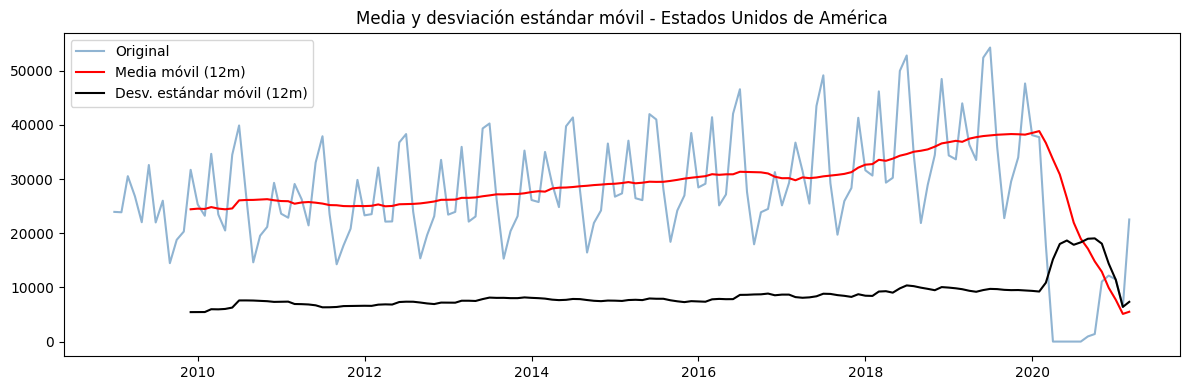

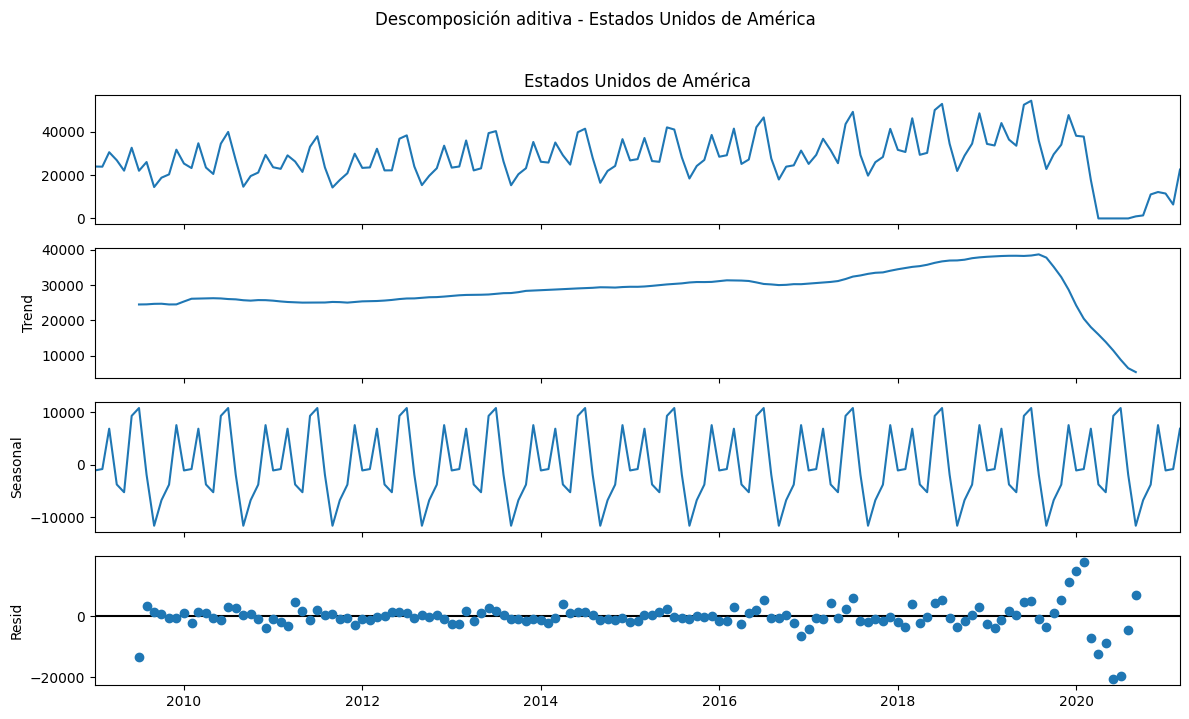

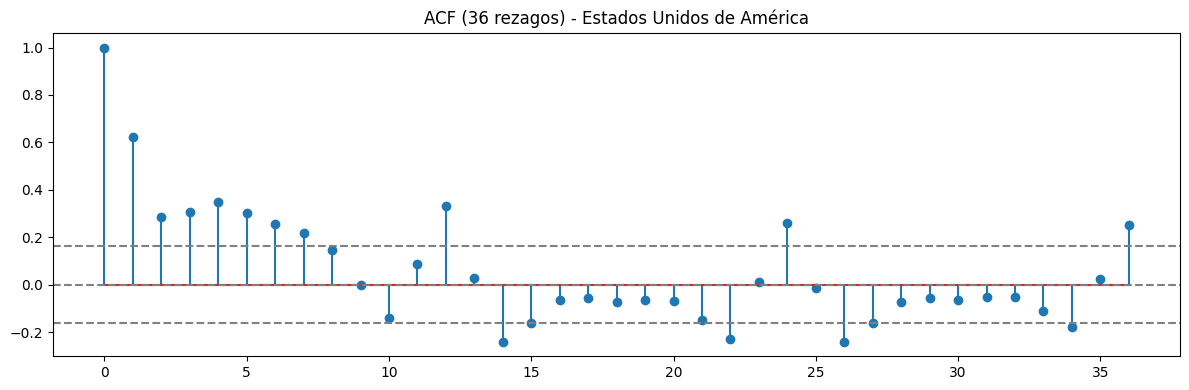


Prueba de Dickey-Fuller Aumentada (nivel):
Estadístico de prueba     -3.2
p-value                    0.0
# rezagos usados          13.0
# observaciones usadas   133.0
Valor crítico (1%)        -3.5
Valor crítico (5%)        -2.9
Valor crítico (10%)       -2.6
dtype: float64
PAÍS: Honduras
Inicio: 2009-01-01  |  Fin: 2021-03-01  |  Frecuencia: Mensual
Número de observaciones: 147
Media: 8,482  |  Desv. estándar: 3,554  |  Mínimo: 0  |  Máximo: 21,343


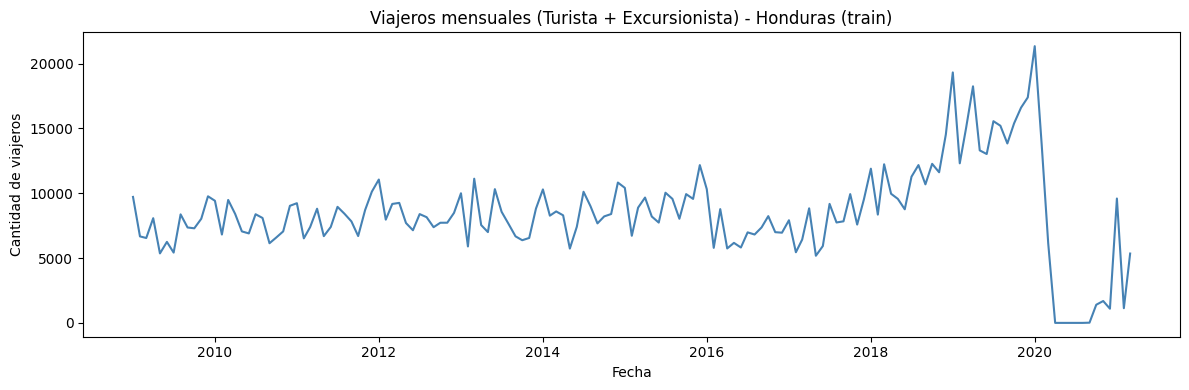

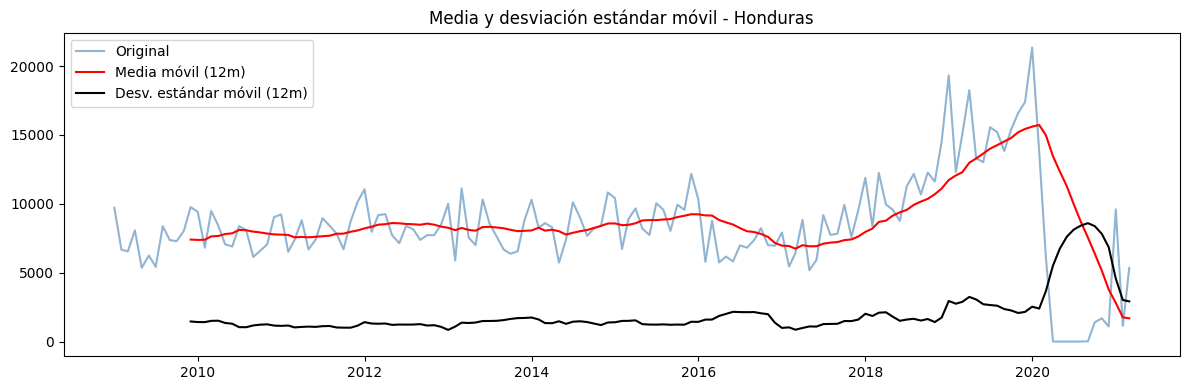

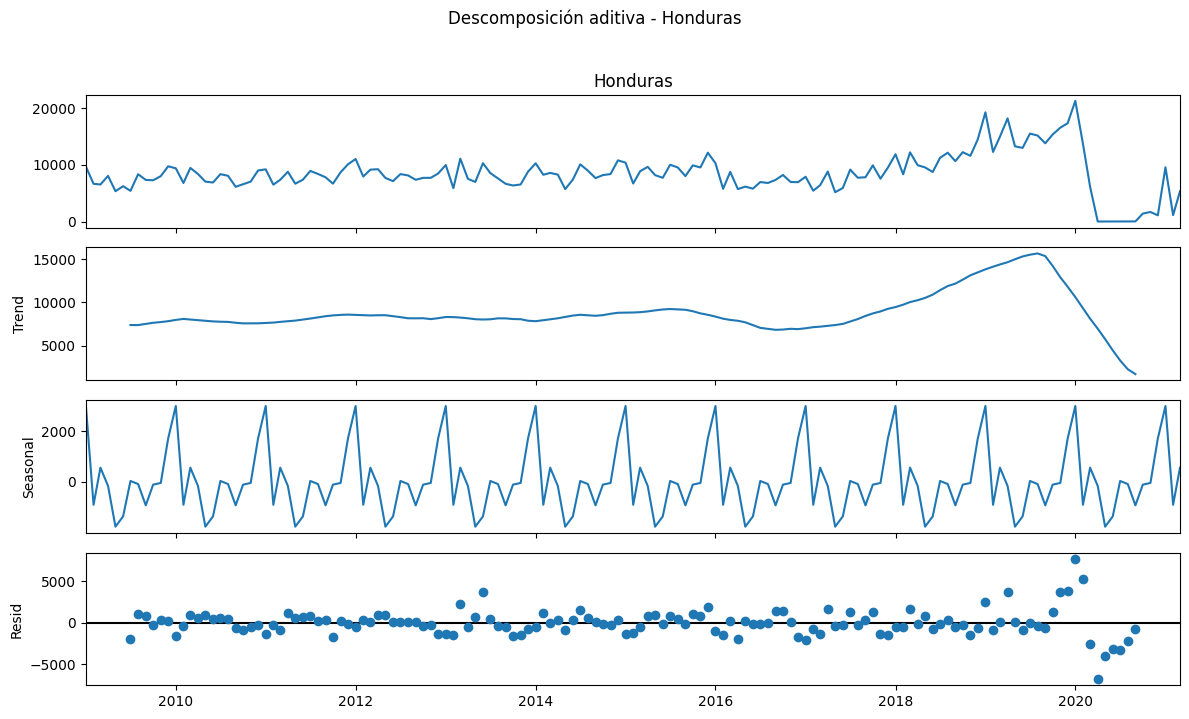

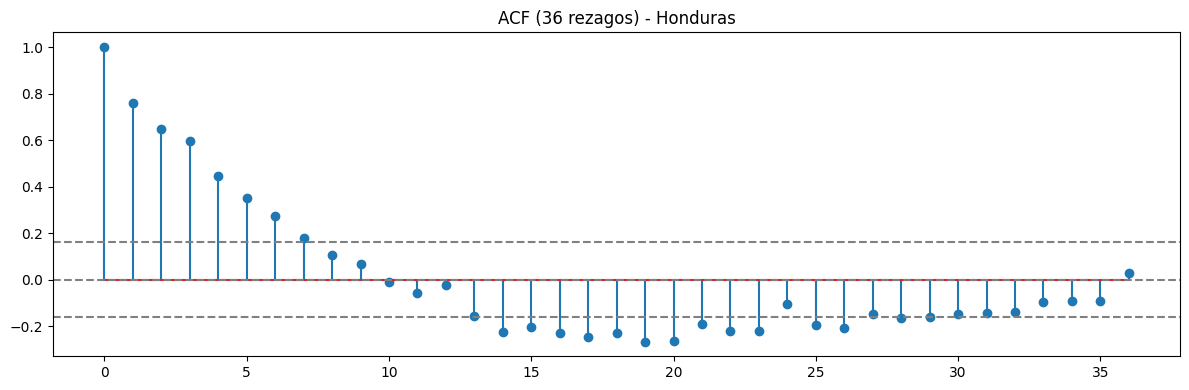


Prueba de Dickey-Fuller Aumentada (nivel):
Estadístico de prueba     -3.7
p-value                    0.0
# rezagos usados          13.0
# observaciones usadas   133.0
Valor crítico (1%)        -3.5
Valor crítico (5%)        -2.9
Valor crítico (10%)       -2.6
dtype: float64


In [15]:
def analisis_preliminar(serie, nombre_pais):
    print("="*70)
    print(f"PAÍS: {nombre_pais}")
    print("="*70)
    print(f"Inicio: {serie.index.min().date()}  |  Fin: {serie.index.max().date()}  |  Frecuencia: Mensual")
    print(f"Número de observaciones: {len(serie)}")
    print(f"Media: {serie.mean():,.0f}  |  Desv. estándar: {serie.std():,.0f}  |  Mínimo: {serie.min():,.0f}  |  Máximo: {serie.max():,.0f}")

    # --- Gráfico de la serie ---
    fig, ax = plt.subplots(figsize=(12,4))
    ax.plot(serie, color='steelblue')
    ax.set_title(f'Viajeros mensuales (Turista + Excursionista) - {nombre_pais} (train)')
    ax.set_xlabel('Fecha')
    ax.set_ylabel('Cantidad de viajeros')
    plt.tight_layout()
    plt.show()

    # --- Media y desviación estándar móvil (12 meses) ---
    rolling_mean = serie.rolling(window=12).mean()
    rolling_std = serie.rolling(window=12).std()
    fig, ax = plt.subplots(figsize=(12,4))
    ax.plot(serie, color='steelblue', label='Original', alpha=0.6)
    ax.plot(rolling_mean, color='red', label='Media móvil (12m)')
    ax.plot(rolling_std, color='black', label='Desv. estándar móvil (12m)')
    ax.set_title(f'Media y desviación estándar móvil - {nombre_pais}')
    ax.legend(loc='best')
    plt.tight_layout()
    plt.show()

    # --- Descomposición ---
    decomp = seasonal_decompose(serie, model='additive', period=12)
    fig = decomp.plot()
    fig.set_size_inches(12, 7)
    fig.suptitle(f'Descomposición aditiva - {nombre_pais}', y=1.02)
    plt.tight_layout()
    plt.show()

    # --- ACF ---
    fig, ax = plt.subplots(figsize=(12,4))
    valores_acf = acf(serie, nlags=36, fft=False)
    ax.stem(range(len(valores_acf)), valores_acf)
    ax.axhline(y=0, linestyle='--', color='gray')
    ax.axhline(y=1.96/np.sqrt(len(serie)), linestyle='--', color='gray')
    ax.axhline(y=-1.96/np.sqrt(len(serie)), linestyle='--', color='gray')
    ax.set_title(f'ACF (36 rezagos) - {nombre_pais}')
    plt.tight_layout()
    plt.show()

    # --- ADF ---
    dftest = adfuller(serie, autolag='AIC')
    out = pd.Series(dftest[0:4], index=['Estadístico de prueba','p-value','# rezagos usados','# observaciones usadas'])
    for key, value in dftest[4].items():
        out[f'Valor crítico ({key})'] = value
    print("\nPrueba de Dickey-Fuller Aumentada (nivel):")
    print(out)

    return decomp, out

resultados = {}
for p in paises_top3:
    resultados[p] = analisis_preliminar(series_train[p], p)


### Interpretación preliminar

**El Salvador**
- La serie muestra una tendencia creciente sostenida entre 2009 y 2020, con un desplome abrupto
  y prácticamente a cero entre abril y agosto de 2020 (cierre de fronteras por COVID-19), seguido
  de una recuperación fuerte a partir de 2021.
- La descomposición muestra un componente estacional claro y repetitivo (picos y valles similares
  cada año), consistente con patrones de vacaciones/temporada alta.
- La media y desviación estándar móviles no son constantes en el tiempo (suben con la tendencia y
  se disparan alrededor de 2020), lo que sugiere **no estacionariedad tanto en media como en
  varianza**.
- El ACF decae muy lentamente (no se anula rápido), típico de una serie con tendencia y raíz
  unitaria. La prueba ADF en nivel arroja un p-value alto (no se rechaza la hipótesis nula de raíz
  unitaria) &rarr; **no estacionaria en media**. Al diferenciar una vez, el p-value cae por debajo
  de 0.05, lo que sugiere que **d=1** sería un punto de partida razonable.

**Estados Unidos de América**
- Tendencia creciente más suave que El Salvador, también con la caída abrupta en 2020 y
  recuperación posterior.
- Estacionalidad visible pero de menor amplitud relativa que El Salvador.
- El resultado de la prueba ADF en nivel resulta significativo (p-value < 0.05); sin embargo, esto
  probablemente se debe a la fuerte caída/recuperación de 2020 (un choque grande "ayuda"
  artificialmente a rechazar la raíz unitaria). Visualmente la serie sí muestra tendencia, por lo
  que **se recomienda confirmar con una diferenciación adicional en el análisis final** y no
  basarse únicamente en el estadístico de la prueba.

**Honduras**
- Patrón similar: tendencia creciente, quiebre en 2020, recuperación posterior, estacionalidad
  presente.
- Al igual que en Estados Unidos, la prueba ADF en nivel resulta significativa, lo cual amerita
  revisión adicional en la entrega final (posible efecto del choque de 2020 sobre la potencia de
  la prueba).

**Conclusión preliminar común a las tres series:**
- Las tres series de "País de Residencia" muestran **tendencia** y **estacionalidad anual**, por
  lo que **no son estacionarias en varianza ni en media** en su forma original.
- El choque de 2020 (pandemia) es el evento más disruptivo en las tres series y deberá tenerse en
  cuenta al seleccionar y validar los modelos (por ejemplo, evaluando si conviene tratarlo como
  atípico o dejar que el modelo lo absorba).
- Para la entrega final se profundizará en: transformación (log, si aplica, para estabilizar
  varianza), número de diferenciaciones necesarias (d), y selección de p/q usando ACF/PACF,
  comparando modelos ARIMA/SARIMA contra Prophet, Holt-Winters, suavizamiento exponencial y
  seasonal naive.
